# 04 - Is aligned

In [66]:
import sys
sys.path.append("/Users/Ana/Documents/Ing Salud/TFG/codigo")

from eogtouch.models.enums import StimuliColor

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (20, 6)

df = pd.read_parquet("/Users/Ana/eog-game-touch/eog-game-touch/ABP_20250813_092519.parquet")


## Rutinas

In [67]:

# Identificar cuándo empieza una fijación (de blanco a azul o verde)
df["prev_color"] = df["stimuli_color"].shift(1)

df["start_fixation"] = (
    (df["prev_color"] == StimuliColor.White.int_value) &
    (df["stimuli_color"].isin([StimuliColor.Green.int_value, StimuliColor.Blue.int_value]))
)

# Identificar cuándo termina una fijación (cuando vuelve a blanco)
df["end_fixation"] = (
    (df["prev_color"].isin([StimuliColor.Green.int_value, StimuliColor.Blue.int_value]) &
    (df["stimuli_color"] == StimuliColor.White.int_value)
    )
)

# Obtener los timestamps de inicio y fin
start_times = df[df["start_fixation"]]["timestamp"].reset_index(drop=True)
end_times = df[df["end_fixation"]]["timestamp"].reset_index(drop=True)

# Asegurarse de que hay pares completos --> evita restar arrays de diferente tamaño 
# o que solo haya inicio porque el usuario cierra antes el programa

min_len = min(len(start_times), len(end_times))
duraciones = end_times[:min_len] - start_times[:min_len]

# Crear DataFrame con resultados
df_resultados = pd.DataFrame({
    "start_time": start_times[:min_len],
    "end_time": end_times[:min_len],
    "fixation_duration_ms": duraciones
})


## Alineación en el tiempo

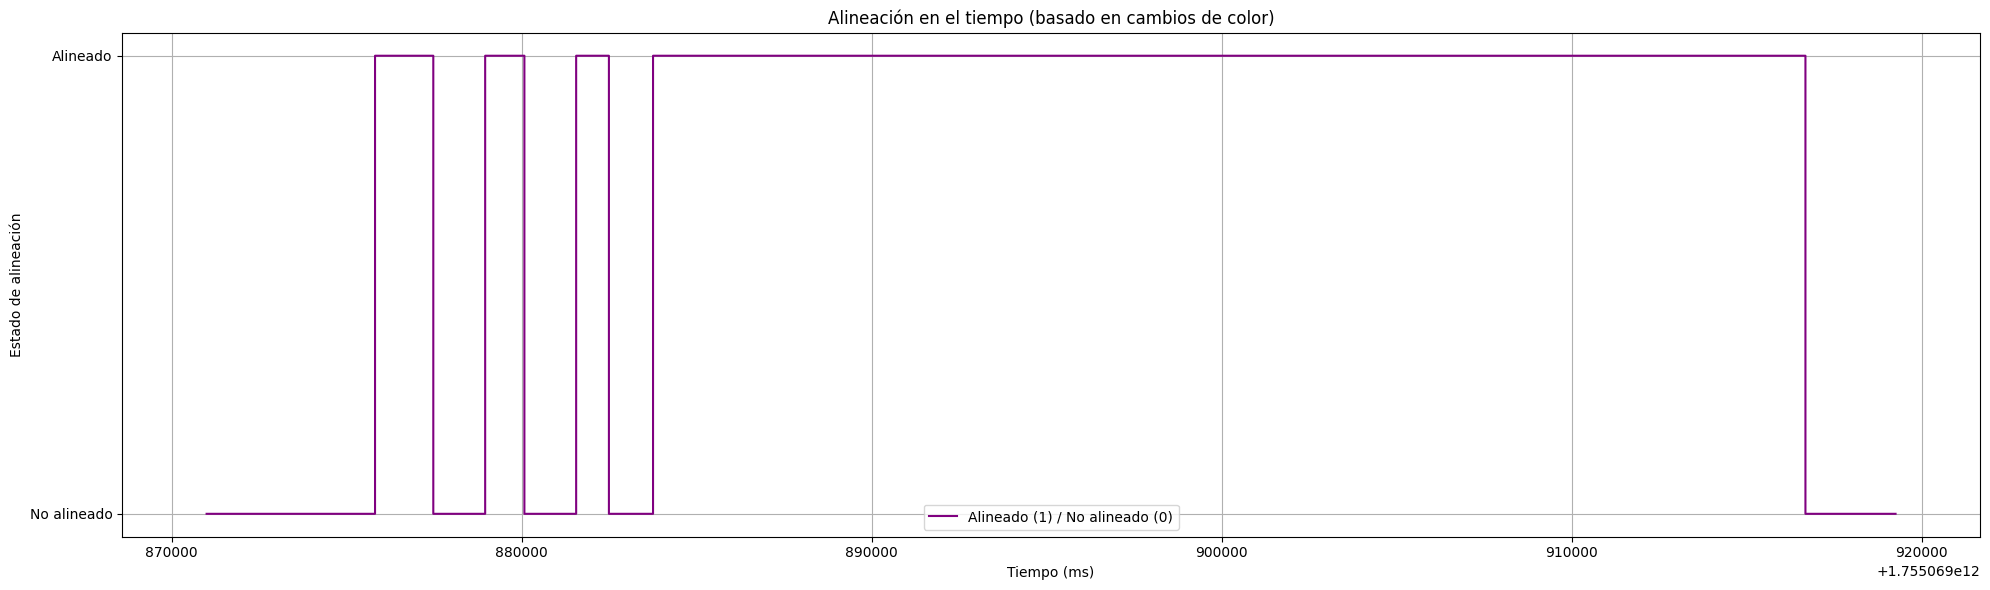

In [68]:
# Inicializar la columna
df["is_aligned"] = False

# Obtener los índices de inicio y fin de cada alineación
start_idx = df.index[df["start_fixation"]].tolist()
end_idx = df.index[df["end_fixation"]].tolist()

# Asegurar que los pares están completos
min_len = min(len(start_idx), len(end_idx))
start_idx = start_idx[:min_len]
end_idx = end_idx[:min_len]

# Rellenar is_aligned = True entre cada par de inicio-fin
for start, end in zip(start_idx, end_idx):
    df.loc[start:end, "is_aligned"] = True



plt.plot(df["timestamp"], df["is_aligned"].astype(int), label="Alineado (1) / No alineado (0)", drawstyle="steps-post", color="purple")
plt.title("Alineación en el tiempo (basado en cambios de color)")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Estado de alineación")
plt.yticks([0, 1], ["No alineado", "Alineado"])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Alineación y color a lo largo del tiempo

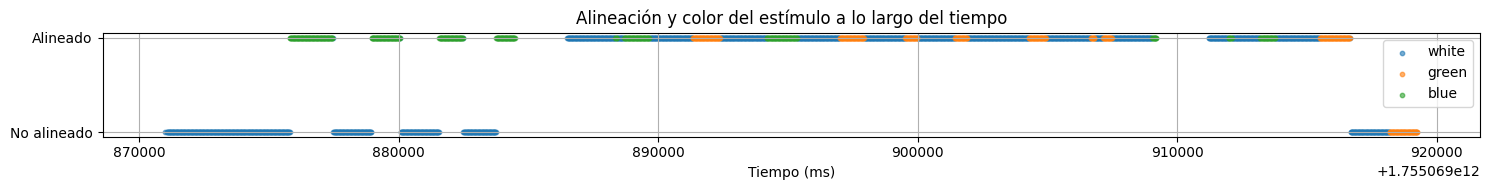

In [69]:
# Colores simplificados
color_map = {
    StimuliColor.White.int_value: "white",
    StimuliColor.Green.int_value: "green",
    StimuliColor.Blue.int_value: "blue"
}

df["color_name"] = df["stimuli_color"].map(color_map)

plt.figure(figsize=(15, 2))

# Usamos scatter para cada punto en el tiempo, codificado por color y alineación
for color in ["white", "green", "blue"]:
    subset = df[df["color_name"] == color]
    plt.scatter(subset["timestamp"], 
                subset["is_aligned"].astype(int), 
                label=color, 
                s=10, alpha=0.6)

plt.yticks([0, 1], ["No alineado", "Alineado"])
plt.title("Alineación y color del estímulo a lo largo del tiempo")
plt.xlabel("Tiempo (ms)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Tiempo alineado respecto a tiempo total

Tiempo total alineado: 36662 ms
Tiempo total de experimento: 48262 ms
Porcentaje de alineación: 75.96 %


Text(0.5, 1.0, 'Porcentaje de tiempo alineado')

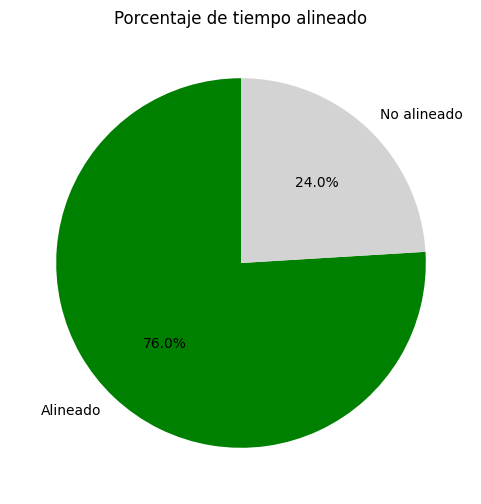

In [70]:

# Diferencia entre muestras sucesivas (en milisegundos)
df["delta_t"] = df["timestamp"].diff().fillna(0)

# Tiempo total alineado
tiempo_alineado = df[df["is_aligned"] == True]["delta_t"].sum()

# Tiempo total del experimento
tiempo_total = df["delta_t"].sum()

# Porcentaje de alineación
porcentaje_alineado = (tiempo_alineado / tiempo_total) * 100

print(f"Tiempo total alineado: {tiempo_alineado:.0f} ms")
print(f"Tiempo total de experimento: {tiempo_total:.0f} ms")
print(f"Porcentaje de alineación: {porcentaje_alineado:.2f} %")

tiempo_no_alineado = tiempo_total - tiempo_alineado
plt.pie([tiempo_alineado, tiempo_no_alineado],
        labels=["Alineado", "No alineado"],
        colors=["green", "lightgray"],
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90)
plt.title("Porcentaje de tiempo alineado")




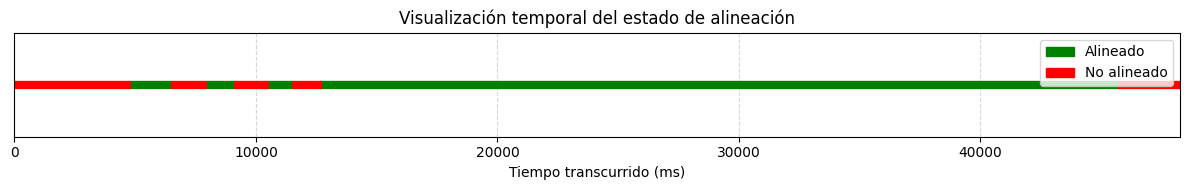

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Asegúrate de tener la diferencia temporal por fila
df["delta_t"] = df["timestamp"].diff().fillna(0)

# Tiempo acumulado en el eje X
x = np.cumsum(df["delta_t"].to_numpy())

# Valor 1 si está alineado, 0 si no (solo para dar altura a la línea)
y = np.ones_like(x)

# Para crear segmentos de línea
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Colores según alineación en el punto inicial
colors = ['green' if aligned else 'red' for aligned in df["is_aligned"].to_numpy()[:-1]]

# Crear y mostrar la línea coloreada
fig, ax = plt.subplots(figsize=(12, 2))
lc = LineCollection(segments, colors=colors, linewidth=6)
ax.add_collection(lc)

ax.set_xlim(x[0], x[-1])
ax.set_ylim(0.9, 1.1)
ax.set_yticks([])
ax.set_xlabel("Tiempo transcurrido (ms)")
ax.set_title("Visualización temporal del estado de alineación")
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Leyenda personalizada
import matplotlib.patches as mpatches
aligned_patch = mpatches.Patch(color='green', label='Alineado')
not_aligned_patch = mpatches.Patch(color='red', label='No alineado')
ax.legend(handles=[aligned_patch, not_aligned_patch], loc="upper right")

plt.tight_layout()
plt.show()


In [72]:
import numpy as np

# Calcular distancia euclídea en cada muestra
df["error_dist"] = np.sqrt((df["stimuli_x"] - df["eyes_x"])**2 + (df["stimuli_y"] - df["eyes_y"])**2)

# Filtrar solo cuando está alineado
df_alineado = df[df["is_aligned"] == True]

# Calcular error medio
error_medio = df_alineado["error_dist"].mean()

print(f"Error medio de alineación (distancia al centro del estímulo): {error_medio:.2f} px")


Error medio de alineación (distancia al centro del estímulo): 78.39 px


## Posición estímulo y sensor (con alineación y sin)

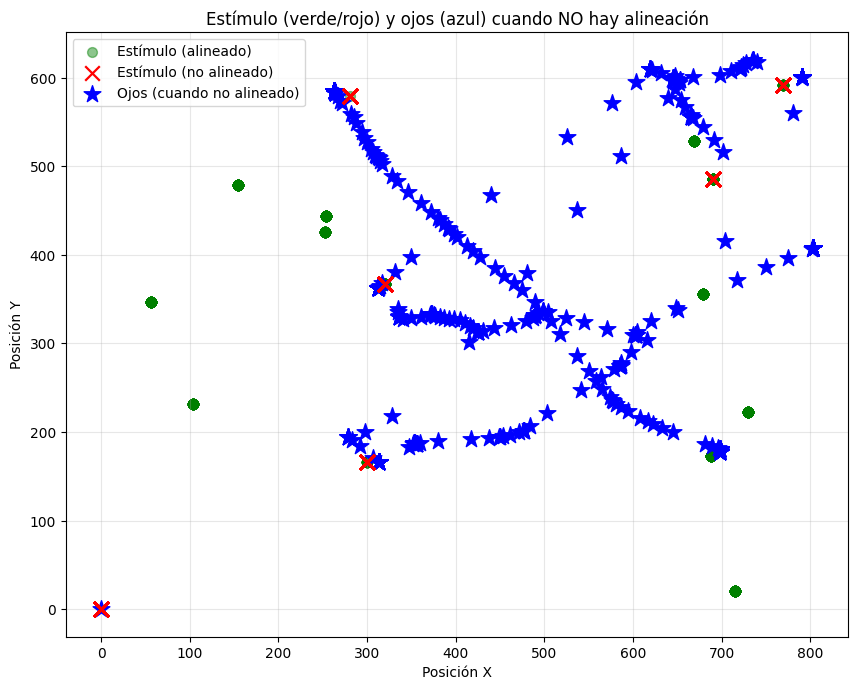

In [73]:
import matplotlib.pyplot as plt

# === 1) Normaliza is_aligned a booleano robusto ===
df["is_aligned"] = (
    df["is_aligned"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "1": True, "yes": True,
          "false": False, "0": False, "no": False})
    .fillna(False)
    .astype(bool)
)

mask_al   = df["is_aligned"]
mask_noal = ~mask_al

plt.figure(figsize=(9, 7))

# --- Estímulo cuando está alineado (solo estímulo) ---
plt.scatter(
    df.loc[mask_al, "stimuli_x"],
    df.loc[mask_al, "stimuli_y"],
    c="green", alpha=0.45, s=50, label="Estímulo (alineado)", zorder=1
)

# --- Estímulo cuando NO está alineado ---
plt.scatter(
    df.loc[mask_noal, "stimuli_x"],
    df.loc[mask_noal, "stimuli_y"],
    c="red", marker="x", s=110, linewidths=1.6,
    label=f"Estímulo (no alineado)", zorder=3
)

# --- Ojos SOLO en los NO alineados ---
plt.scatter(
    df.loc[mask_noal, "eyes_x"],
    df.loc[mask_noal, "eyes_y"],
    c="blue", marker="*", s=160,
    label="Ojos (cuando no alineado)", zorder=2
)

# (Opcional) misma escala si X e Y comparten unidades
plt.gca().set_aspect("equal", adjustable="box")

plt.title("Estímulo (verde/rojo) y ojos (azul) cuando NO hay alineación")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


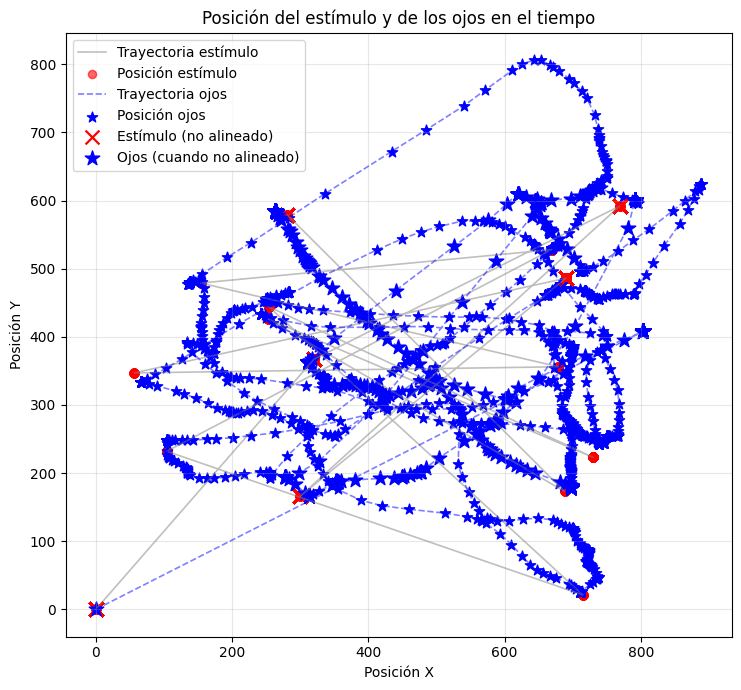

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# --- Trayectoria del estímulo (línea + puntos) ---
plt.plot(df["stimuli_x"], df["stimuli_y"],
         color="gray", alpha=0.5, linewidth=1.2, label="Trayectoria estímulo")
plt.scatter(df["stimuli_x"], df["stimuli_y"],
            c="red", s=35, alpha=0.6, label="Posición estímulo")

# --- Trayectoria de los ojos (línea + puntos) ---
plt.plot(df["eyes_x"], df["eyes_y"],
         color="blue", alpha=0.5, linewidth=1.2, linestyle="--", label="Trayectoria ojos")
plt.scatter(df["eyes_x"], df["eyes_y"],
            c="blue", marker="*", s=60, label="Posición ojos")

# --- Opcional: resaltar no alineados ---
mask_noal = ~df["is_aligned"]
plt.scatter(df.loc[mask_noal, "stimuli_x"], df.loc[mask_noal, "stimuli_y"],
            c="red", marker="x", s=100, linewidths=1.6, label="Estímulo (no alineado)")
plt.scatter(df.loc[mask_noal, "eyes_x"], df.loc[mask_noal, "eyes_y"],
            c="blue", marker="*", s=120, label="Ojos (cuando no alineado)")

# --- Formato ---
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Posición del estímulo y de los ojos en el tiempo")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


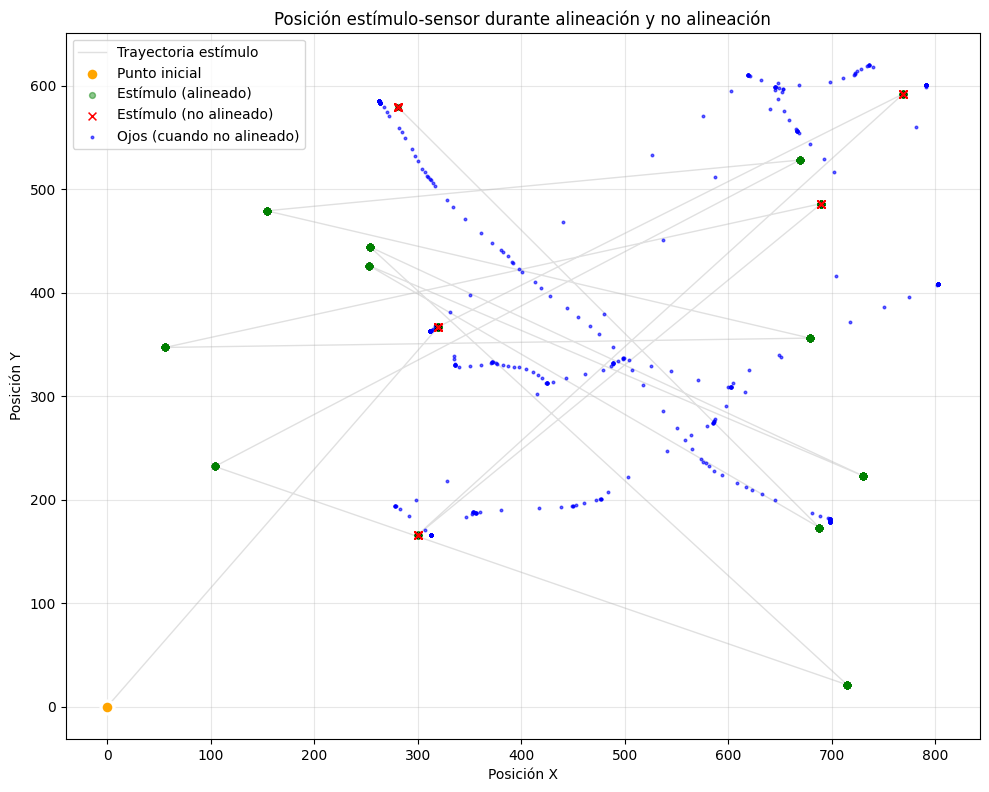

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# === Ajustes ===
SHOW_EYES = True  # pon False si solo quieres el estímulo por colores

# === Asegurar tipos y limpiar NaN ===
df = df.copy()
df["is_aligned"] = df["is_aligned"].astype(bool)
df = df.dropna(subset=["stimuli_x","stimuli_y"])

# === Identificar punto inicial ===
# Asumiendo que el punto inicial es (0,0) - ajusta si es diferente
mask_initial = (df["stimuli_x"] == 0) & (df["stimuli_y"] == 0)
mask_al = df["is_aligned"] & ~mask_initial  # alineados (sin punto inicial)
mask_noal = ~df["is_aligned"] & ~mask_initial  # no alineados (sin punto inicial)

plt.figure(figsize=(10, 8))

# (1) Trayectoria del estímulo (todas las muestras, para contexto)
plt.plot(df["stimuli_x"].values, df["stimuli_y"].values,
         color="lightgray", linewidth=1.0, alpha=0.7, label="Trayectoria estímulo", zorder=0)

# (2) Punto inicial (starting point)
if mask_initial.any():
    plt.scatter(
        df.loc[mask_initial, "stimuli_x"],
        df.loc[mask_initial, "stimuli_y"],
        c="orange", marker="o", s=80, edgecolors="white", linewidth=2,
        label="Punto inicial", zorder=4
    )

# (3) Estímulo cuando está alineado
plt.scatter(
    df.loc[mask_al, "stimuli_x"],
    df.loc[mask_al, "stimuli_y"],
    c="green", s=18, alpha=0.45,
    label="Estímulo (alineado)", zorder=1
)

# (4) Estímulo cuando NO está alineado
plt.scatter(
    df.loc[mask_noal, "stimuli_x"],
    df.loc[mask_noal, "stimuli_y"],
    c="red", marker="x", s=32, linewidths=1.1,
    label="Estímulo (no alineado)", zorder=3
)

# (5) (Opcional) Ojos SOLO en los no alineados
if SHOW_EYES and {"eyes_x","eyes_y"}.issubset(df.columns):
    plt.scatter(
        df.loc[mask_noal, "eyes_x"],
        df.loc[mask_noal, "eyes_y"],
        c="blue", marker=".", s=14, alpha=0.6,
        label="Ojos (cuando no alineado)", zorder=2
    )

# Misma escala si X e Y comparten unidades
plt.gca().set_aspect("equal", adjustable="box")

plt.title("Posición estímulo-sensor durante alineación y no alineación")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

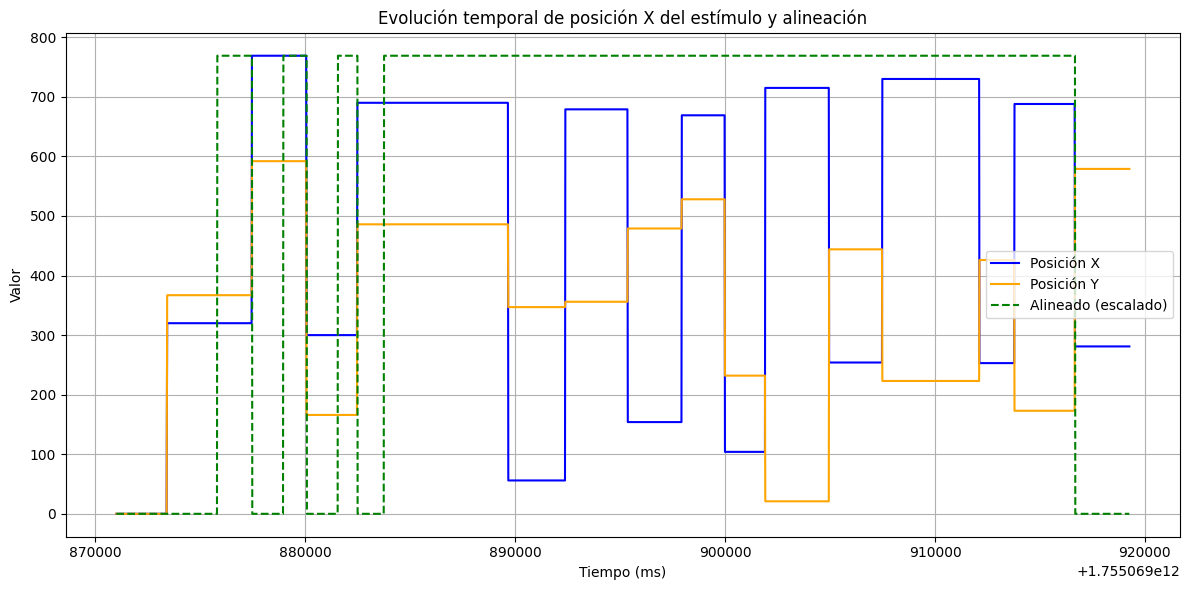

In [76]:
plt.figure(figsize=(12, 6))

# Línea temporal de estímulo en X y alineación
plt.plot(df["timestamp"], df["stimuli_x"], label="Posición X", color="blue")
plt.plot(df["timestamp"], df["stimuli_y"], label="Posición Y", color="orange")
plt.plot(df["timestamp"], df["is_aligned"].astype(int) * df["stimuli_x"].max(), 
         label="Alineado (escalado)", color="green", linestyle="--")

plt.title("Evolución temporal de posición X del estímulo y alineación")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Evolución de la alineación estímulo - ojos

Se evalua la posición 2D del estímulo y analiza su alineación.  
Se representa en rojo la desalineación y en verde la alineación a lo largo del estudio.

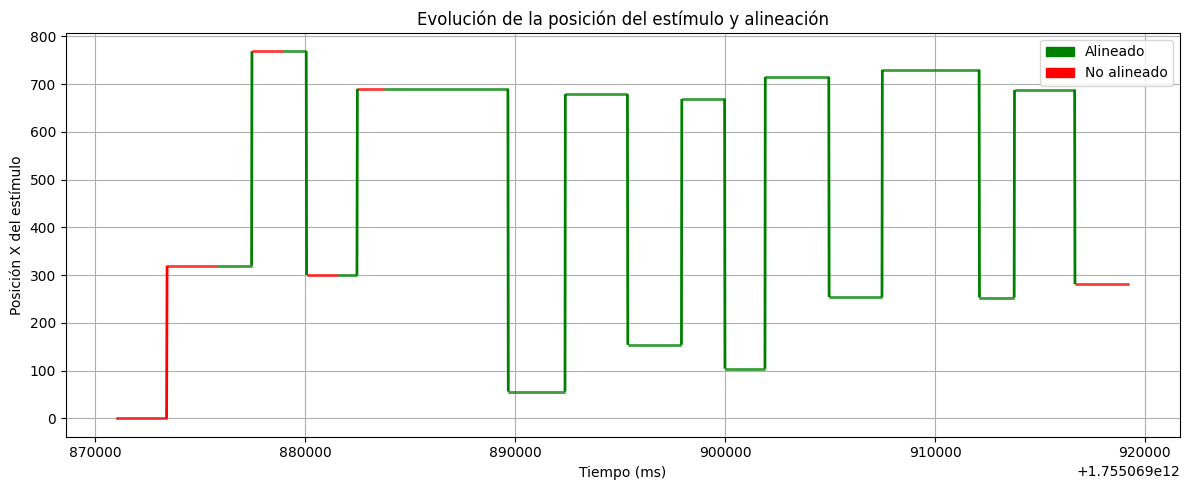

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Variables
x = df["timestamp"].to_numpy()
y = df["stimuli_x"].to_numpy()  # Puedes usar también 'stimuli_y' si quieres

# Estado de alineación (booleano)
aligned = df["is_aligned"].to_numpy()

# Crear segmentos de línea (timestamp vs posición)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Colores: verde si alineado, rojo si no (basado en punto inicial del segmento)
colors = ['green' if a else 'red' for a in aligned[:-1]]

# Crear LineCollection
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.add_collection(lc)
ax.autoscale()
ax.set_title("Evolución de la posición del estímulo y alineación")
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Posición X del estímulo")
ax.grid(True)

# Añadir leyenda manual
import matplotlib.patches as mpatches
aligned_patch = mpatches.Patch(color='green', label='Alineado')
not_aligned_patch = mpatches.Patch(color='red', label='No alineado')
plt.legend(handles=[aligned_patch, not_aligned_patch])

plt.tight_layout()
plt.show()


## Porcentaje de alineación en cada posición

Porcentaje de alineación respecto al tiempo según cada posición del estímulo 

            tiempo_total  tiempo_alineado  porcentaje_alineado
pos                                                           
(56, 347)         2720.0           2720.0           100.000000
(104, 232)        1923.0           1923.0           100.000000
(154, 479)        2574.0           2574.0           100.000000
(253, 426)        1670.0           1670.0           100.000000
(254, 444)        2534.0           2534.0           100.000000
(688, 173)        2881.0           2881.0           100.000000
(679, 356)        2974.0           2974.0           100.000000
(669, 528)        2055.0           2055.0           100.000000
(730, 223)        4628.0           4628.0           100.000000
(715, 21)         3041.0           3041.0           100.000000
(690, 486)        7192.0           5938.0            82.563960
(769, 592)        2603.0           1123.0            43.142528
(320, 367)        4050.0           1649.0            40.716049
(300, 166)        2416.0            937.0            38

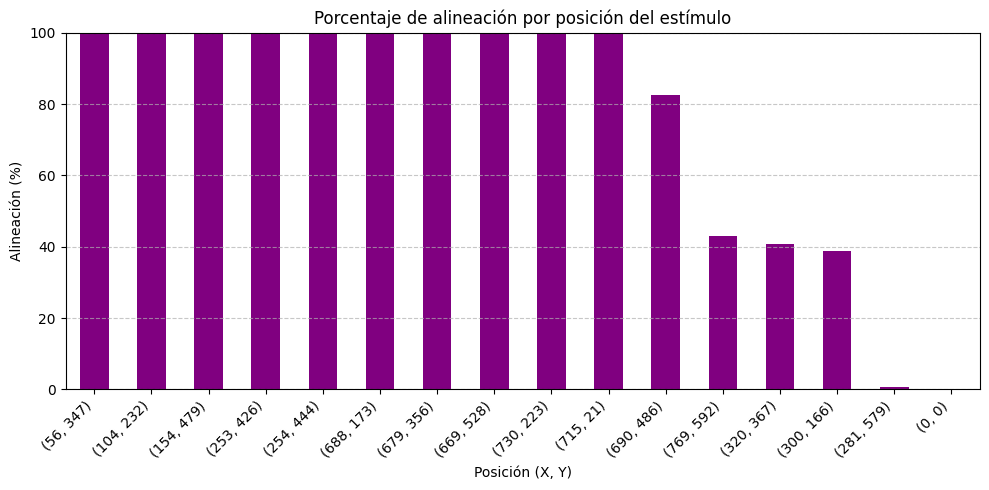

In [78]:
# Calcular diferencia temporal entre muestras
df["delta_t"] = df["timestamp"].diff().fillna(0)

# Crear clave de posición (X, Y)
df["pos"] = list(zip(df["stimuli_x"], df["stimuli_y"]))

# Tiempo total por posición
tiempo_total_por_pos = df.groupby("pos")["delta_t"].sum()

# Tiempo alineado por posición
tiempo_alineado_por_pos = df[df["is_aligned"] == True].groupby("pos")["delta_t"].sum()

# Combinar en un solo DataFrame
df_posiciones = pd.DataFrame({
    "tiempo_total": tiempo_total_por_pos,
    "tiempo_alineado": tiempo_alineado_por_pos
}).fillna(0)

# Calcular el porcentaje de alineación
df_posiciones["porcentaje_alineado"] = (df_posiciones["tiempo_alineado"] / df_posiciones["tiempo_total"]) * 100

# Ordenar
df_posiciones = df_posiciones.sort_values(by="porcentaje_alineado", ascending=False)

# Mostrar
print(df_posiciones)

# Gráfico de barras: porcentaje de alineación por posición
plt.figure(figsize=(10, 5))
df_posiciones["porcentaje_alineado"].plot(kind="bar", color="purple")

plt.title("Porcentaje de alineación por posición del estímulo")
plt.ylabel("Alineación (%)")
plt.xlabel("Posición (X, Y)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


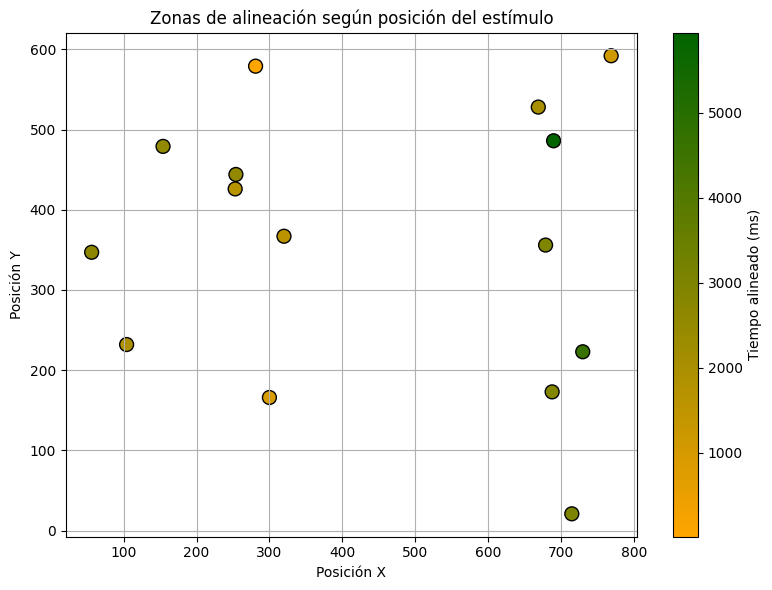

In [79]:

# Tiempo por posición
df["delta_t"] = df["timestamp"].diff().fillna(0)
df["pos"] = list(zip(df["stimuli_x"], df["stimuli_y"]))

# Tiempo alineado por posición
tiempo_alineado = df[df["is_aligned"] == True].groupby("pos")["delta_t"].sum()

# Separar X, Y, tiempo
x_pos = [p[0] for p in tiempo_alineado.index]
y_pos = [p[1] for p in tiempo_alineado.index]
tiempo = tiempo_alineado.values

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Crear mapa de colores de naranja claro a verde oscuro
custom_cmap = mcolors.LinearSegmentedColormap.from_list("naranja-verde", ["orange", "darkgreen"])

# Graficar
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pos, y_pos, c=tiempo, cmap=custom_cmap, s=100, edgecolor='black')
plt.colorbar(scatter, label="Tiempo alineado (ms)")

plt.title("Zonas de alineación según posición del estímulo")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.grid(True)
plt.tight_layout()
plt.show()





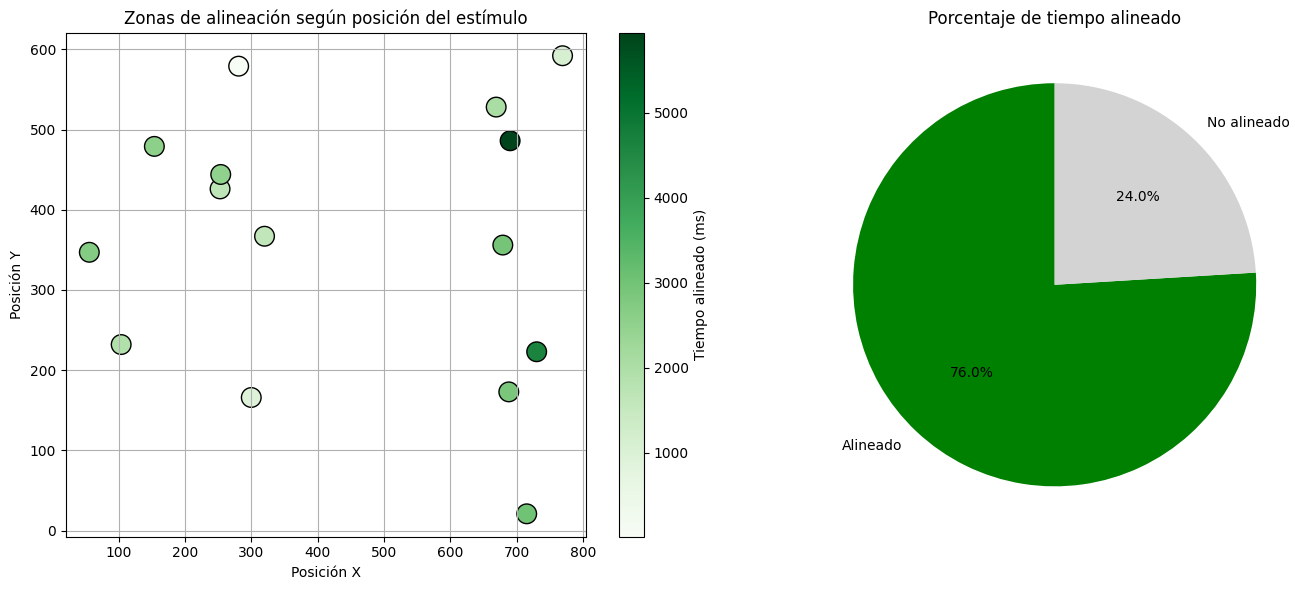

In [80]:
import matplotlib.pyplot as plt

# --- Calcular el tiempo alineado y total ---
df["delta_t"] = df["timestamp"].diff().fillna(0)
tiempo_alineado = df[df["is_aligned"] == True]["delta_t"].sum()
tiempo_total = df["delta_t"].sum()
porcentaje_alineado = (tiempo_alineado / tiempo_total) * 100

# --- Calcular tiempo alineado por posición del estímulo ---
df["pos"] = list(zip(df["stimuli_x"], df["stimuli_y"]))
tiempo_por_pos = df[df["is_aligned"] == True].groupby("pos")["delta_t"].sum()
x_pos = [p[0] for p in tiempo_por_pos.index]
y_pos = [p[1] for p in tiempo_por_pos.index]
tiempos = tiempo_por_pos.values

# --- Crear figura con dos subgráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subgráfico 1: Mapa de calor de alineación por posición
sc = ax1.scatter(x_pos, y_pos, c=tiempos, cmap="Greens", s=200, edgecolor='black')
cb = plt.colorbar(sc, ax=ax1)
cb.set_label("Tiempo alineado (ms)")

ax1.set_title("Zonas de alineación según posición del estímulo")
ax1.set_xlabel("Posición X")
ax1.set_ylabel("Posición Y")
ax1.grid(True)

# Subgráfico 2: Quesito de tiempo alineado vs no alineado
tiempo_no_alineado = tiempo_total - tiempo_alineado
ax2.pie([tiempo_alineado, tiempo_no_alineado],
        labels=["Alineado", "No alineado"],
        colors=["green", "lightgray"],
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90)
ax2.set_title("Porcentaje de tiempo alineado")

# Ajustar el diseño
plt.tight_layout()
plt.show()


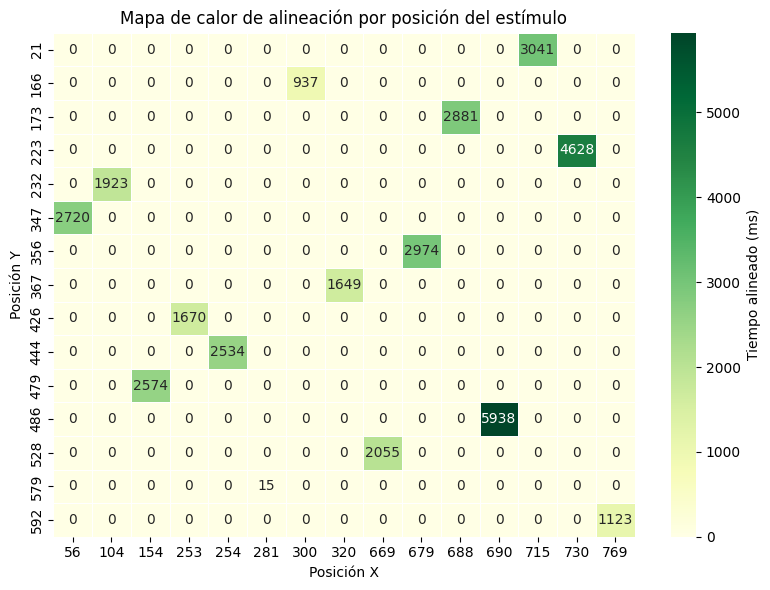

In [81]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Crear DataFrame desde posiciones y tiempos
df_heatmap = pd.DataFrame({
    "x": x_pos,
    "y": y_pos,
    "tiempo": tiempo
})

# Crear tabla pivote (como matriz X-Y)
pivot = df_heatmap.pivot_table(index="y", columns="x", values="tiempo", fill_value=0)

# Mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, cmap="YlGn", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Tiempo alineado (ms)'})
plt.title("Mapa de calor de alineación por posición del estímulo")
plt.xlabel("Posición X")
plt.ylabel("Posición Y")
plt.tight_layout()
plt.show()


In [82]:
# Calcular distancia (error) en píxeles
df["error_dist"] = np.sqrt((df["stimuli_x"] - df["eyes_x"])**2 + (df["stimuli_y"] - df["eyes_y"])**2)

# Calcular el error como porcentaje del error máximo
max_error = df["error_dist"].max()
df["error_pct"] = (df["error_dist"] / max_error) * 100


## Error relativo respecto al centro del estímulo durante la alineación

Error relativo entre el centro del estímulo y la posición de los ojos cuando hay alineación.  
Cada punto representa un error relativo

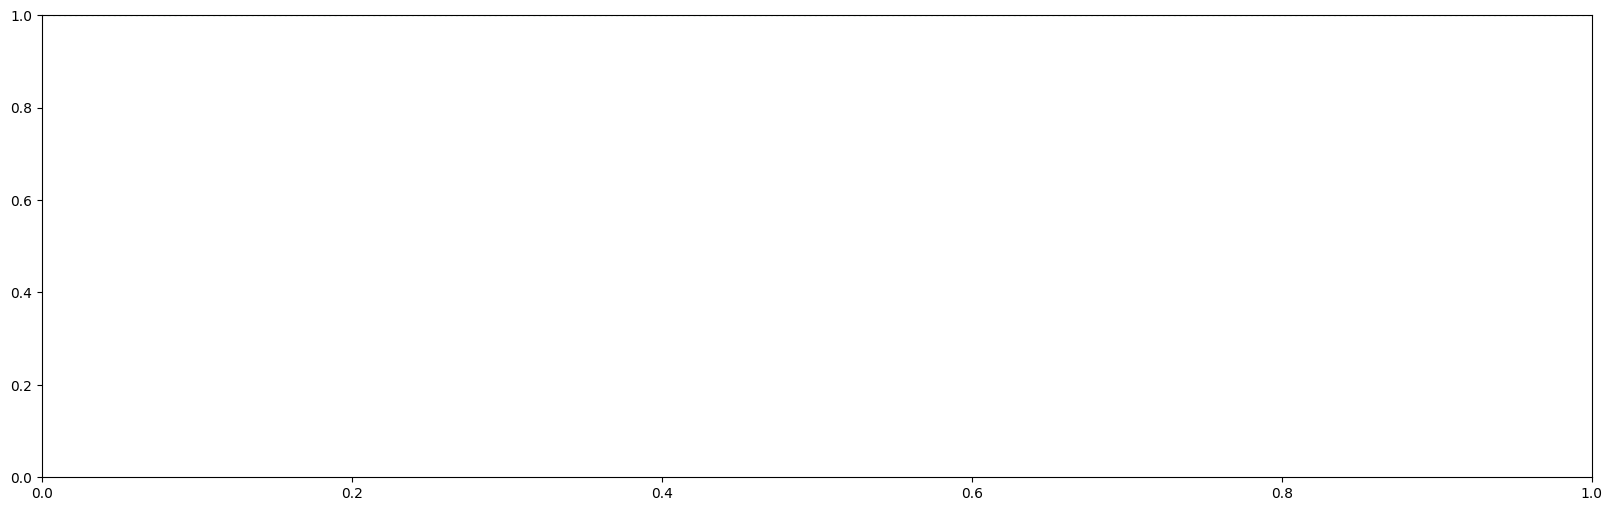

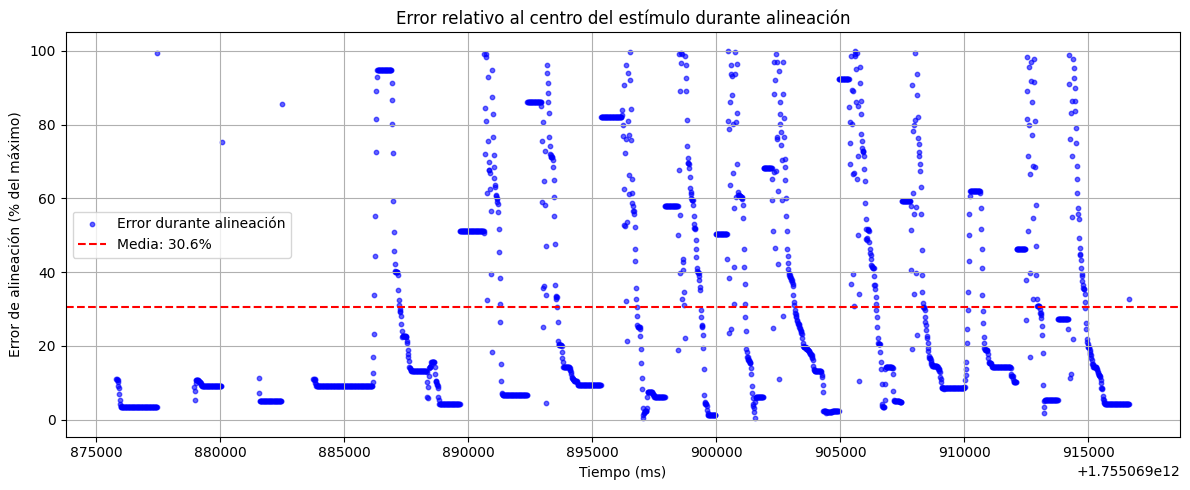

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular distancia en píxeles
df["error_dist"] = np.sqrt((df["stimuli_x"] - df["eyes_x"])**2 + (df["stimuli_y"] - df["eyes_y"])**2)

# 2. Convertir a porcentaje del máximo observado
max_error = df["error_dist"].max()
df["error_pct"] = (df["error_dist"] / max_error) * 100

# 3. Filtrar solo momentos alineados
df_alineado = df[df["is_aligned"] == True]

umbral_bueno = 1  # % del error máximo permitido
plt.axhline(umbral_bueno, color="green", linestyle=":", label=f"Umbral aceptable ({umbral_bueno}%)")


# 4. Scatter plot: error en % en cada instante alineado
plt.figure(figsize=(12, 5))
plt.scatter(df_alineado["timestamp"], df_alineado["error_pct"],
            c="blue", s=10, alpha=0.6, label="Error durante alineación")

# Media del error
media_error_pct = df_alineado["error_pct"].mean()
plt.axhline(media_error_pct, color="red", linestyle="--", label=f"Media: {media_error_pct:.1f}%")

# Formato del gráfico
plt.title("Error relativo al centro del estímulo durante alineación")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Error de alineación (% del máximo)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


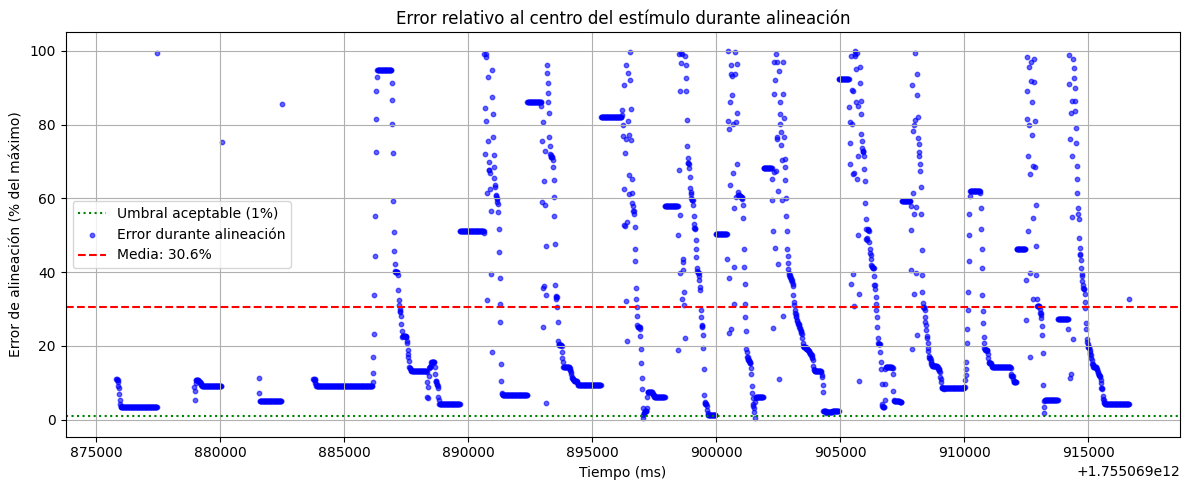

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular distancia en píxeles
df["error_dist"] = np.sqrt((df["stimuli_x"] - df["eyes_x"])**2 + (df["stimuli_y"] - df["eyes_y"])**2)

# 2. Convertir a porcentaje del máximo observado
max_error = df["error_dist"].max()
df["error_pct"] = (df["error_dist"] / max_error) * 100

# 3. Filtrar solo momentos alineados
df_alineado = df[df["is_aligned"] == True]

# 4. Crear figura antes de dibujar nada
plt.figure(figsize=(12, 5))

# 5. Dibujar el umbral y la media
umbral_bueno = 1  # % del error máximo permitido
plt.axhline(umbral_bueno, color="green", linestyle=":", label=f"Umbral aceptable ({umbral_bueno}%)")

# 6. Dibujar puntos y media
plt.scatter(df_alineado["timestamp"], df_alineado["error_pct"],
            c="blue", s=10, alpha=0.6, label="Error durante alineación")

media_error_pct = df_alineado["error_pct"].mean()
plt.axhline(media_error_pct, color="red", linestyle="--", label=f"Media: {media_error_pct:.1f}%")

# 7. Formato del gráfico
plt.title("Error relativo al centro del estímulo durante alineación")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Error de alineación (% del máximo)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Error relativo en histograma

Cálculo del error relativo (centro estímulo y pos ojos) y representación por histograma. 
Se calcula también la media de errores a modo representativo.

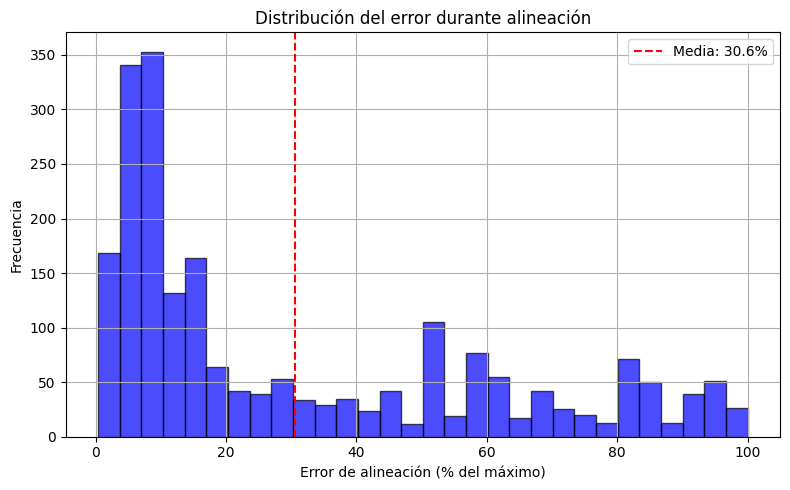

In [85]:
plt.figure(figsize=(8, 5))
plt.hist(df_alineado["error_pct"], bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.axvline(media_error_pct, color="red", linestyle="--", label=f"Media: {media_error_pct:.1f}%")
plt.title("Distribución del error durante alineación")
plt.xlabel("Error de alineación (% del máximo)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Evolución error medio a lo largo del tiempo

Representa el error medio por bloque de tiempo. 
En este caso está puesto cada 1 segundo, pero puede adaptarse al bloque de tiempo que se quiera.  
Proporciona una idea de si conforme avanza el estudio, hay más fallos o menos (si la persona se cansa más, se despista o atiende más y acierta
por repetición y asimilación del juego)

C:\Users\Ana\AppData\Local\Temp\ipykernel_4924\2003194722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_alineado.loc[:, "time_block"] = (df_alineado["timestamp"] // 1000).astype(int)


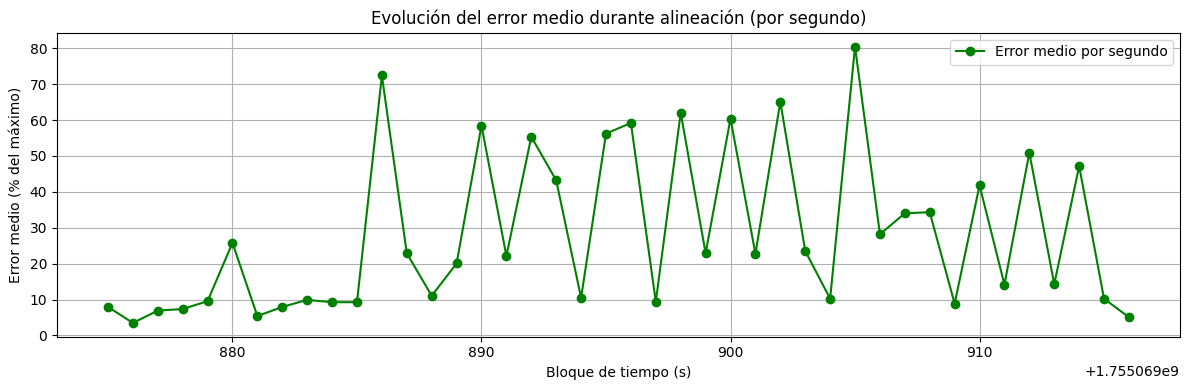

In [86]:
# Crear columna de bloques de tiempo 
df_alineado.loc[:, "time_block"] = (df_alineado["timestamp"] // 1000).astype(int)

# df_alineado es una copia parcial del DataFrame df, y no está garantizado que los cambios que hagas allí sean estables o seguros. 
# .loc indica explícitamente que estás asignando en una copia

# Error medio por bloque
errores_bloque = df_alineado.groupby("time_block")["error_pct"].mean()

# Gráfico
plt.figure(figsize=(12, 4))
plt.plot(errores_bloque.index, errores_bloque.values, marker="o", color="green")
plt.title("Evolución del error medio durante alineación (por segundo)")
plt.xlabel("Bloque de tiempo (s)")
plt.ylabel("Error medio (% del máximo)")
plt.grid(True)
plt.tight_layout()
plt.legend(["Error medio por segundo"], loc="upper right")
plt.show()


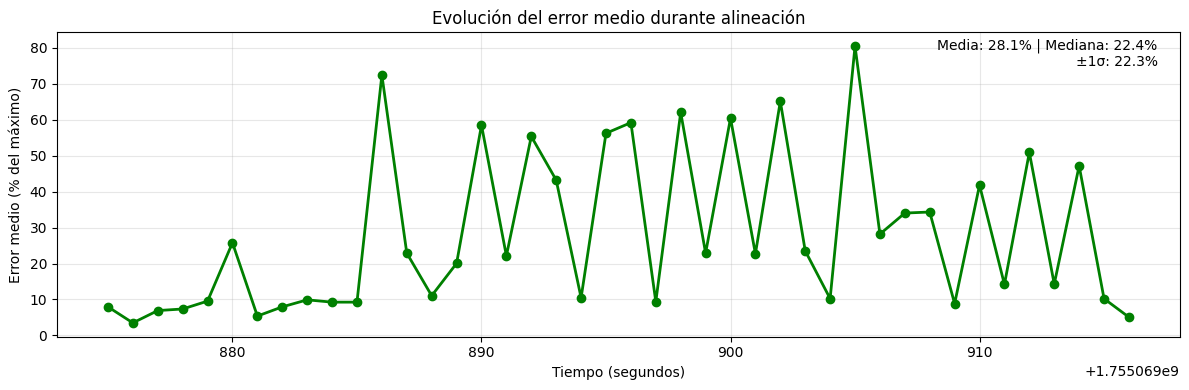


Estadísticas del error por segundo:
Media: 28.10%
Mediana: 22.42%
Desviación estándar: 22.28%
Mínimo: 3.49%
Máximo: 80.44%


In [87]:
# Crear columna de bloques de tiempo 
df_alineado.loc[:, "time_block"] = (df_alineado["timestamp"] // 1000).astype(int)

# Error medio por bloque
errores_bloque = df_alineado.groupby("time_block")["error_pct"].mean()

# Gráfico
plt.figure(figsize=(12, 4))
plt.plot(errores_bloque.index, errores_bloque.values, marker="o", color="green", linewidth=2)
plt.title("Evolución del error medio durante alineación")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Error medio (% del máximo)")
plt.grid(True, alpha=0.3)

stats_text = f"Media: {errores_bloque.mean():.1f}% | Mediana: {errores_bloque.median():.1f}%\n±1σ: {errores_bloque.std():.1f}%"
plt.text(0.98, 0.98, stats_text, transform=plt.gca().transAxes, 
         ha='right', va='top', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# Imprimir estadísticas detalladas
print(f"\nEstadísticas del error por segundo:")
print(f"Media: {errores_bloque.mean():.2f}%")
print(f"Mediana: {errores_bloque.median():.2f}%")
print(f"Desviación estándar: {errores_bloque.std():.2f}%")
print(f"Mínimo: {errores_bloque.min():.2f}%")
print(f"Máximo: {errores_bloque.max():.2f}%")